# Generation: Features
- Extracts features from 1k images of each generator and real images
- Uses t-SNE to plot the feature clusters
- Runs on gpu/cpu

In [1]:
import os
import glob
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.manifold import TSNE

real_images_dir = "30kds_real_face_crop_dlib/Real"
dcgan_generated_dir = "generated/dcgan"
stylegan_generated_dir = "generated/stylegan"

In [2]:
class ImageFolderDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

def get_image_paths(directory, extensions=["png", "jpg", "jpeg"]):
    paths = []
    for ext in extensions:
        paths.extend(glob.glob(os.path.join(directory, f"*.{ext}")))
    return paths

# Inception v3 expects images of size 299x299 and normalized with ImageNet statistics.
transform_pipeline = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

real_paths = get_image_paths(real_images_dir)
dcgan_paths = get_image_paths(dcgan_generated_dir)
stylegan_paths = get_image_paths(stylegan_generated_dir)

In [3]:
if len(real_paths) > 1000:
    real_paths = random.sample(real_paths, 1000)

print(f"Found {len(real_paths)} real, {len(dcgan_paths)} DCGAN, and {len(stylegan_paths)} StyleGAN images.")

# Create datasets and dataloaders
batch_size = 32
real_dataset = ImageFolderDataset(real_paths, transform=transform_pipeline)
dcgan_dataset = ImageFolderDataset(dcgan_paths, transform=transform_pipeline)
stylegan_dataset = ImageFolderDataset(stylegan_paths, transform=transform_pipeline)

real_loader = DataLoader(real_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
dcgan_loader = DataLoader(dcgan_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
stylegan_loader = DataLoader(stylegan_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

Found 1000 real, 1000 DCGAN, and 1000 StyleGAN images.


In [4]:
# Load pretrained Inception v3 and modify for feature extraction
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.inception_v3(weights=True, transform_input=False)
# Replace the final classification layer with an identity to extract features
model.fc = torch.nn.Identity()
model.to(device)
model.eval()

def extract_features(dataloader, model, device):
    features = []
    with torch.no_grad():
        for imgs in dataloader:
            imgs = imgs.to(device)
            output = model(imgs)
            features.append(output.cpu().numpy())
    features = np.concatenate(features, axis=0)
    return features

print("Extracting features for real images...")
real_features = extract_features(real_loader, model, device)
print("Extracting features for DCGAN images...")
dcgan_features = extract_features(dcgan_loader, model, device)
print("Extracting features for StyleGAN images...")
stylegan_features = extract_features(stylegan_loader, model, device)

c:\Users\danie\anaconda3\envs\DL\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\danie\anaconda3\envs\DL\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\danie/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [01:36<00:00, 1.13MB/s] 


Extracting features for real images...
Extracting features for DCGAN images...
Extracting features for StyleGAN images...


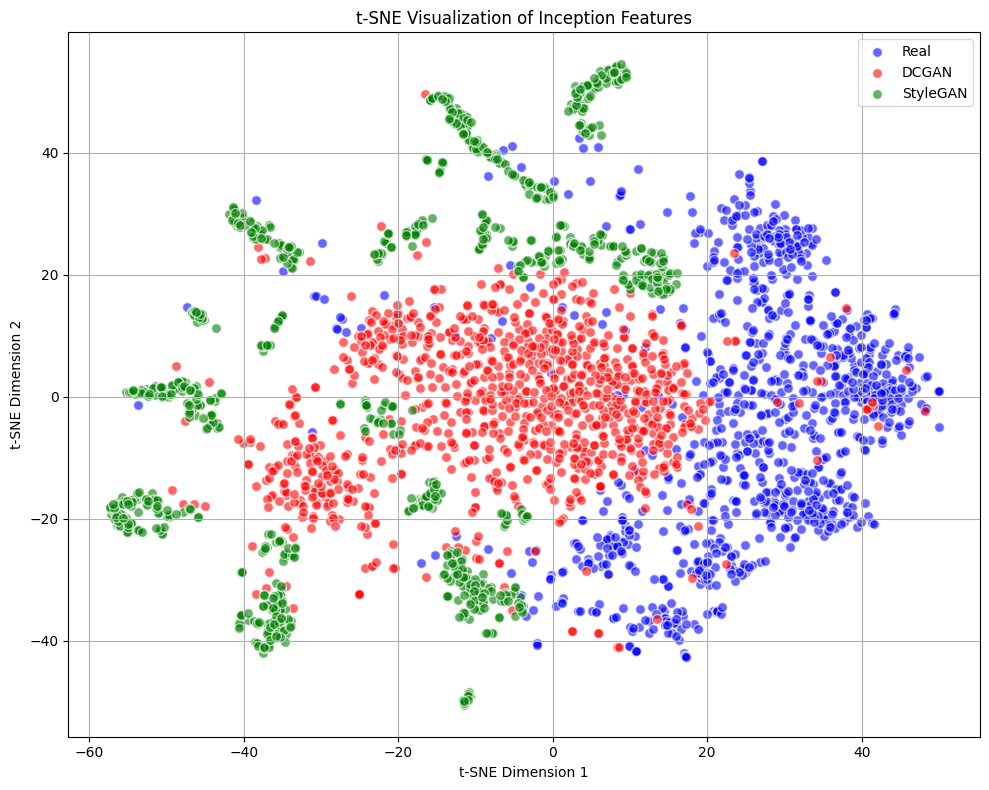

In [5]:
# 0 = Real, 1 = DCGAN, 2 = StyleGAN
features = np.concatenate([real_features, dcgan_features, stylegan_features], axis=0)
labels = np.array([0]*len(real_features) + [1]*len(dcgan_features) + [2]*len(stylegan_features))
label_names = {0: "Real", 1: "DCGAN", 2: "StyleGAN"}

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
features_tsne = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(features_tsne[idx, 0], features_tsne[idx, 1],
                c=colors[label], label=label_names[label], alpha=0.6, edgecolors='w', s=50)
plt.title("t-SNE Visualization of Inception Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()